# Clasificación de sentimiento: EDA (Análisis exploratorio de los datos) 
En esta celda, vamos a visualizar los datos de nuestro dataset artificial para crear un modelo de NLP que clasifique el prompt introducido por el usuario en 4 categorías:
- Inaceptable
- Alto riesgo
- Riesgo limitado
- Riesgo mínimo

Esto es un ejercicio similar al análisis de sentimiento que hemos realizado durante el módulo, pero en este caso, se conoce como text classification supervisada multiclase, no sentiment analysis. 


In [15]:
import sys
import os

# Localizar src/classifier/ de forma robusta y ajustar cwd al directorio
# de este notebook para que rutas relativas (datasets/, data/, model/) funcionen
# independientemente de desde donde se lance Jupyter/VS Code.
_cwd = os.getcwd()
_candidates = [
    os.path.join(_cwd, "src", "classifier"),
    os.path.abspath(".."),
    os.path.abspath("."),
]
for _p in _candidates:
    if os.path.isfile(os.path.join(_p, "functions.py")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        # Cambiar cwd al directorio de este notebook
        os.chdir(os.path.join(_p, "classifier_dataset_real"))
        break

import functions  # noqa: E402
functions.MLFLOW_EXPERIMENT = "clasificador_riesgo_ia_real"
functions._DATASET_TAGS = {"dataset_type": "real", "dataset_source": "eu_ai_act_flagged"}

In [16]:
#Al principio de cada notebook, añadimos estas líneas para que se recarguen automáticamente las funciones que hayamos editado en el módulo functions.py sin tener que reiniciar el kernel cada vez.
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Carga del dataset 
Cargamos el dataset y lo guardamos en archivos separados 

In [17]:
# Abrimos el dataset
import pandas as pd
path = "datasets/eu_ai_act_flagged_es.csv"
df = pd.read_csv(path)
# Separamos las características (X) y la variable objetivo (y)
X = df["descripcion"]
y = df["etiqueta"]


# Imprimimos las formas de los conjuntos de entrenamiento y prueba
print("Conjunto:", X.shape, y.shape)

Conjunto: (600,) (600,)


# Primer acercamiento a los datos: 

1. Verificaciones básicas
Objetivo: confirmar que no hay nulos ni clases desbalanceadas.
2. Comprobar duplicados
3. Longitud de los textos
4. Limpieza mínima del texto
5. Generación de un word cloud para comprobar las palabras más utilizadas 

In [18]:
#Comprobamos si nuestro dataset tenía duplicados antes de la división
df.duplicated().sum()

np.int64(0)

In [19]:
# Mostramos las primeras filas del conjunto de entrenamiento
X.head()
# Mostramos las últimas filas del conjunto de entrenamiento
X.tail()


595    Sistema de optimización de la iluminación en m...
596    Herramienta de análisis de biodiversidad marin...
597    Sistema de generación automática de recetas de...
598    Herramienta de análisis de contratos de sumini...
599    Sistema de monitorización del estado de equipo...
Name: descripcion, dtype: object

In [20]:
# Mostramos las últimas filas del conjunto de entrenamiento
y.head()
# mostramos las últimas filas del conjunto de entrenamiento
y.tail()

595    riesgo_minimo
596    riesgo_minimo
597    riesgo_minimo
598    riesgo_minimo
599    riesgo_minimo
Name: etiqueta, dtype: object

<Axes: xlabel='etiqueta'>

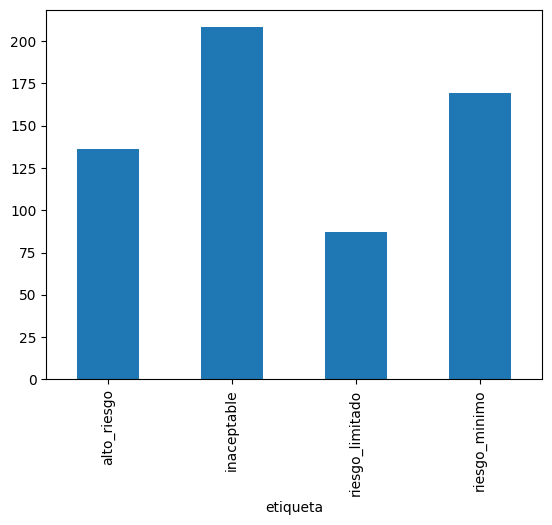

In [21]:
# Comprobamos la distribución de las etiquetas en el conjunto de entrenamiento
df['etiqueta'].value_counts().sort_index().plot(kind='bar')

# 1️ Distribución de clases:
Como vemos en el gráfico anterior, el dataset está bastante equilibrado:
- alto_riesgo ≈ 90
- inaceptable ≈ 77
- riesgo_limitado ≈ 67
- riesgo_minimo ≈ 66


In [22]:
# Analizamos la longitud de las descripciones para ver si hay alguna diferencia entre las clases
df["longitud"] = df["descripcion"].apply(len)
df["longitud"].describe()

count    600.000000
mean     249.713333
std       78.811335
min       41.000000
25%      185.000000
50%      218.500000
75%      312.250000
max      559.000000
Name: longitud, dtype: float64

In [23]:
# Comprobamos el tamaño del vocabulario bruto
raw_vocab = set(" ".join(df['descripcion']).split())
len(raw_vocab)

3237

In [24]:
#Creamos una nueva columna con el texto limpio
from functions import limpiar_texto

df["descripcion_limpia"] = df["descripcion"].apply(limpiar_texto)

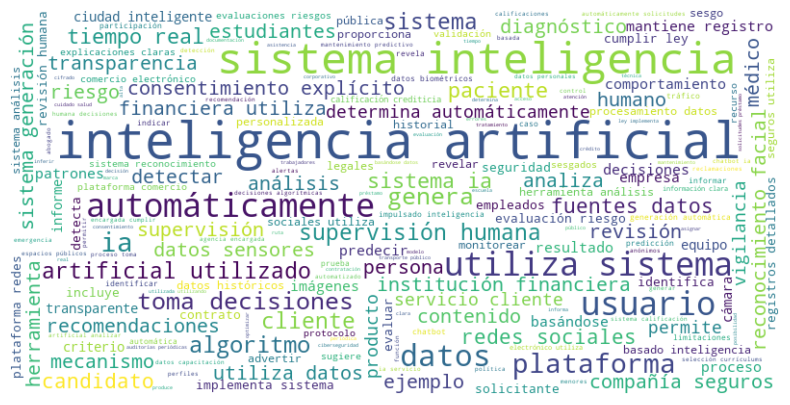

In [25]:
#Creamos un wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Unimos todas las descripciones limpias en un solo texto
texto_completo = " ".join(df["descripcion_limpia"])
# Creamos el wordcloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(texto_completo)
# Mostramos el wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# Wordcloud
Palabras dominantes:
- sistema
- algoritmo
- automáticamente
- supervisión
- revisión
- herramienta
- usuario
- biométrica
- reconocimiento
- Interpretación:

El dataset gira alrededor de cuatro ejes claros:

- Automatización
- Supervisión humana
- Identificación biométrica
- Impacto sobre personas

Eso encaja perfectamente con el AI Act.


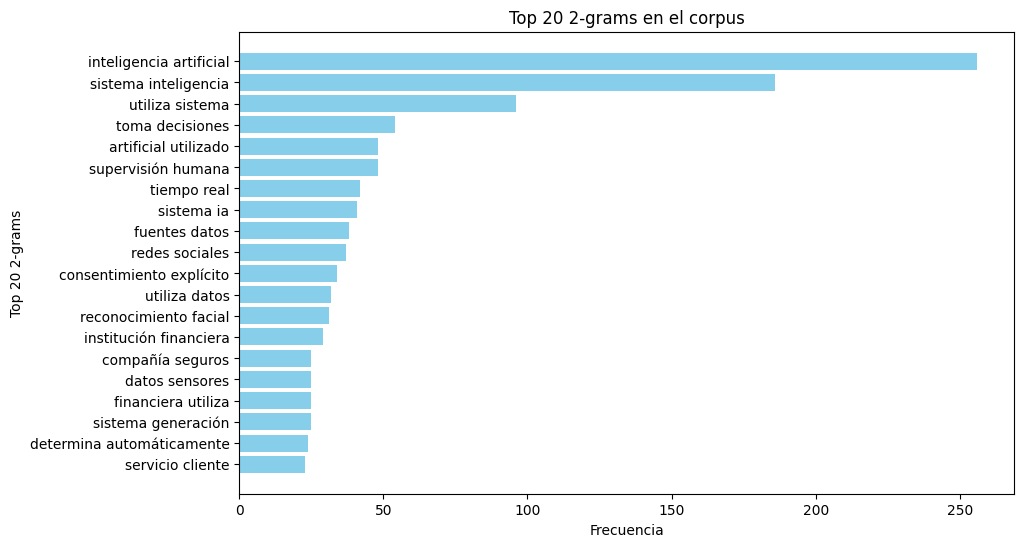

[('inteligencia artificial', 256), ('sistema inteligencia', 186), ('utiliza sistema', 96), ('toma decisiones', 54), ('artificial utilizado', 48), ('supervisión humana', 48), ('tiempo real', 42), ('sistema ia', 41), ('fuentes datos', 38), ('redes sociales', 37), ('consentimiento explícito', 34), ('utiliza datos', 32), ('reconocimiento facial', 31), ('institución financiera', 29), ('compañía seguros', 25), ('datos sensores', 25), ('financiera utiliza', 25), ('sistema generación', 25), ('determina automáticamente', 24), ('servicio cliente', 23)]


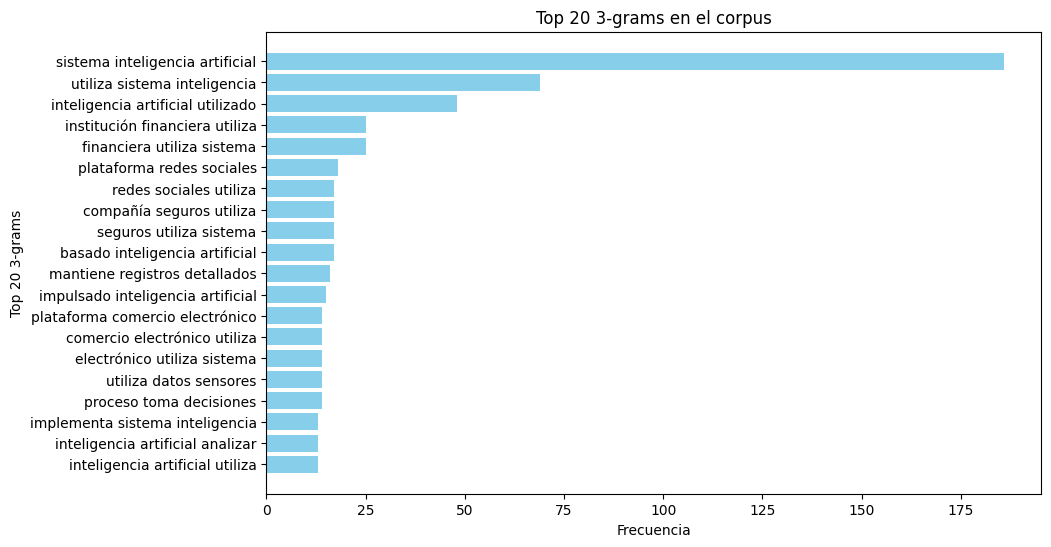

[('sistema inteligencia artificial', 186), ('utiliza sistema inteligencia', 69), ('inteligencia artificial utilizado', 48), ('institución financiera utiliza', 25), ('financiera utiliza sistema', 25), ('plataforma redes sociales', 18), ('redes sociales utiliza', 17), ('compañía seguros utiliza', 17), ('seguros utiliza sistema', 17), ('basado inteligencia artificial', 17), ('mantiene registros detallados', 16), ('impulsado inteligencia artificial', 15), ('plataforma comercio electrónico', 14), ('comercio electrónico utiliza', 14), ('electrónico utiliza sistema', 14), ('utiliza datos sensores', 14), ('proceso toma decisiones', 14), ('implementa sistema inteligencia', 13), ('inteligencia artificial analizar', 13), ('inteligencia artificial utiliza', 13)]


In [26]:
#Comprobamos los n-gramas más comunes
from functions import top_ngrams
print(top_ngrams(df, n=20, ngram=2))
print(top_ngrams(df, n=20, ngram=3))

# N-grams (2 y 3)
Ahora el corpus refleja señal semántica real:
Aparecen patrones como:
- “determina automáticamente”
- “revisión humana”
- “identificación biométrica”
- “reconocimiento facial”
- “evaluación riesgo”
- “tiempo real”
- “genera automáticamente”
Conclusión:
El texto contiene vocabulario discriminativo.
El modelo puede aprender reglas regulatorias reales.
La limpieza eliminó bastante ruido estructural.

# Conclusiones del análisis exploratorio: 
(En este caso, recopilo todo lo comprendido anteriormente y añado algunas ideas más que surgen después de tener visión del conjunto)
 1️ Distribución de clases
El dataset está bastante equilibrado:
- alto_riesgo ≈ 90
- inaceptable ≈ 77
- riesgo_limitado ≈ 67
- riesgo_minimo ≈ 66

2️ N-grams (2 y 3)
Ahora el corpus refleja señal semántica real:
Aparecen patrones como:
- “determina automáticamente”
- “revisión humana”
- “identificación biométrica”
- “reconocimiento facial”
- “evaluación riesgo”
- “tiempo real”
- “genera automáticamente”

Conclusión:
El texto contiene vocabulario discriminativo.
El modelo puede aprender reglas regulatorias reales.
La limpieza eliminó bastante ruido estructural.

3️ Wordcloud
Palabras dominantes:
- sistema
- algoritmo
- automáticamente
- supervisión
- revisión
- herramienta
- usuario
- biométrica
- reconocimiento
- Interpretación:

El dataset gira alrededor de cuatro ejes claros:

- Automatización
- Supervisión humana
- Identificación biométrica
- Impacto sobre personas

Eso encaja perfectamente con el AI Act.

4️ Riesgo potencial detectado
Aún hay redacción relativamente homogénea:
Muchos textos empiezan por:
- “sistema…”
- “algoritmo…”
- “herramienta…”

Riesgo:
El modelo puede aprender patrones editoriales además de patrones legales.
No es crítico ahora, pero a futuro conviene introducir variabilidad lingüística.

5️ Señales fuertes que el modelo puede usar
- Muy probablemente el clasificador aprende asociaciones como:
- biométrico + tiempo real → inaceptable
- revisión humana → riesgo limitado
- determina automáticamente → alto riesgo
- advertir / identificar como IA → limitado
- consentimiento / vulnerabilidad → inaceptable
- Eso es coherente con la regulación.

6️ Conclusión general del EDA

Nuestro dataset, generado artificialmente utilizando IA:

- Está bien balanceado
- Tiene vocabulario regulatorio claro
- Tiene patrones discriminativos útiles
- Es adecuado para ML clásico
- Es suficientemente rico para intentar fine-tuning después

Debilidad principal:
Homogeneidad estilística.

In [27]:
# Guardamos el dataset limpio para usarlo en el siguiente notebook
df.to_csv("datasets/eu_ai_act_flagged_es_limpio.csv", index=False)

In [28]:
# ── MLflow (solo falla esta celda si el servidor no está disponible) ──
from functions import log_mlflow_safe

dist = df["etiqueta"].value_counts()

try:
    log_mlflow_safe(
        run_name="eda",
        params={
            "n_samples": len(df),
            "n_clases": df["etiqueta"].nunique(),
            "text_column": "descripcion",
            "raw_vocab_size": len(set(" ".join(df["descripcion"]).split())),
        },
        metrics={
            "n_alto_riesgo":     int(dist.get("alto_riesgo", 0)),
            "n_inaceptable":     int(dist.get("inaceptable", 0)),
            "n_riesgo_limitado": int(dist.get("riesgo_limitado", 0)),
            "n_riesgo_minimo":   int(dist.get("riesgo_minimo", 0)),
            "longitud_media":    round(df["longitud"].mean(), 2),
            "longitud_std":      round(df["longitud"].std(), 2),
        },
    )
    print("✓ EDA registrado en MLflow")
except Exception as e:
    print(f"⚠ MLflow no disponible: {e}")

Password obtenida desde variable de entorno local.
MLflow configurado correctamente → https://18.201.64.41/


c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '18.201.64.41'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '18.201.64.41'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '18.201.64.41'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\r

✓ Run 'eda' registrado en MLflow (https://18.201.64.41/)
✓ EDA registrado en MLflow
